In [19]:
import pandas as pd
import matplotlib.pyplot as plt

dataset_path = '../data/merged'

Nasze ostateczne zbiory danych po złączeniu:
1. Reżyserzy
    - imię i nazwisko reżysera
    - powiązane id filmu

In [10]:
directors = pd.read_csv(f"{dataset_path}/directors_named.csv")
directors.head()

,tconst,directors,primaryName
0,tt0000001,nm0005690,William K.L. Dickson
1,tt0000002,nm0721526,Émile Reynaud
2,tt0000003,nm0721526,Émile Reynaud
3,tt0000004,nm0721526,Émile Reynaud
4,tt0000005,nm0005690,William K.L. Dickson


2. Scenarzyści
    - imię i nazwisko scenarzysty
    - powiązane id filmu

In [7]:
writers = pd.read_csv(f"{dataset_path}/writers_named.csv")
writers.head()

,tconst,writers,primaryName
0,tt0000001,\N,NaN
1,tt0000002,\N,NaN
2,tt0000003,nm0721526,Émile Reynaud
3,tt0000004,\N,NaN
4,tt0000005,\N,NaN


3. Baza o filmach MovieLens połączona z danych Worldwide Boc Office
    - tytuł filmu
    - czy dla dorosłych
    - rok produkcji
    - dochód w kraju
    - dochód za granicą
    - dochód całkowity
    - czas trwania
    - gatunki
    - słowa klucze

In [14]:
movie_lens = pd.read_csv(f"{dataset_path}/worldWide_imdb_movieLens_merged.csv")
print(movie_lens.shape)
movie_lens.head()

(9790, 14)


,tconst,imdbId,tmdbId,movieId,primaryTitle,isAdult,year_x,domestic_million_usd,overseas_million_usd,world_million_usd,runtimeMinutes,genres_x,genres_y,top_5_tags
0,tt0003471,3471,96128.0,135706,Traffic in Souls,0,1913.0,1.0,NaN,1.0,88,"Crime,Drama",Drama,NaN
1,tt0005059,5059,415021.0,168578,The Captive,0,1915.0,0.1,NaN,0.1,50,"Drama,Romance,War",(no genres listed),NaN
2,tt0005393,5393,402388.0,270428,The Girl of the Golden West,0,1915.0,0.1,NaN,0.1,45,"Drama,Romance,Western",Romance|Western,NaN
3,tt0006333,6333,30266.0,62383,"20,000 Leagues Under the Sea",0,1916.0,8.0,NaN,8.0,105,"Action,Adventure,Sci-Fi",Action|Adventure|Sci-Fi,"based on a book, original, silent, science fic..."
4,tt0008329,8329,400749.0,167812,Mothers of Men,0,1917.0,NaN,0.0,0.0,60,Drama,Drama,NaN


4. Baza filmów TMDB
    - przychód
    - obsada
    - data produkcji
    - język oryginalny
    - miara popularności
    - oceny
    - gatunki
    - kraj produkcji
    - języki używane w filmie
    - reżyszerzy
    - scenarzyści
    - słowa klucze

In [15]:
tmdb = pd.read_csv("../data/tmdb/final_tmdb_data.csv")
print(tmdb.shape)
tmdb.head()

(9660, 17)


,tmdbId,title,budget,revenue,release_date,runtime,original_language,popularity,vote_average,vote_count,genres,origin_countries,spoken_languages,directors,writers,cast,keywords
0,30266.0,"20,000 Leagues Under the Sea",200000,8000000,1916-12-24,99,en,0.5860,6.164,61,"Adventure, Drama, Action, Science Fiction",United States of America,No Language,Stuart Paton,NaN,"Allen Holubar, Jane Gail, Howard Crampton, Mat...","revenge, captain nemo"
1,42511.0,Orphans of the Storm,0,0,1921-12-28,150,en,0.6853,6.773,97,"Drama, History, Romance",United States of America,No Language,D.W. Griffith,D.W. Griffith,"Lillian Gish, Dorothy Gish, Joseph Schildkraut...","paris, france, french revolution, based on pla..."
2,35227.0,Foolish Wives,1100000,400200,1922-01-11,143,en,1.9550,6.396,101,"Drama, Thriller",United States of America,No Language,Erich von Stroheim,Erich von Stroheim,"Erich von Stroheim, Rudolph Christians, Miss D...","court, monte carlo, wig"
3,22596.0,Safety Last!,121000,1500000,1923-04-01,73,en,1.5000,7.726,565,"Comedy, Romance",United States of America,No Language,"Sam Taylor, Fred C. Newmeyer","Hal Roach, Sam Taylor, Tim Whelan","Harold Lloyd, Mildred Davis, Bill Strother, No...","police, department store, clock, climbing, bla..."
4,32600.0,Seven Chances,0,0,1925-03-15,56,en,4.3555,7.500,318,"Comedy, Romance",United States of America,No Language,Buster Keaton,"David Belasco, Clyde Bruckman, Jean C. Havez, ...","Buster Keaton, T. Roy Barnes, Snitz Edwards, R...","clock, countdown, bride, time, inheritance, ch..."


Wstępne wizualizacje

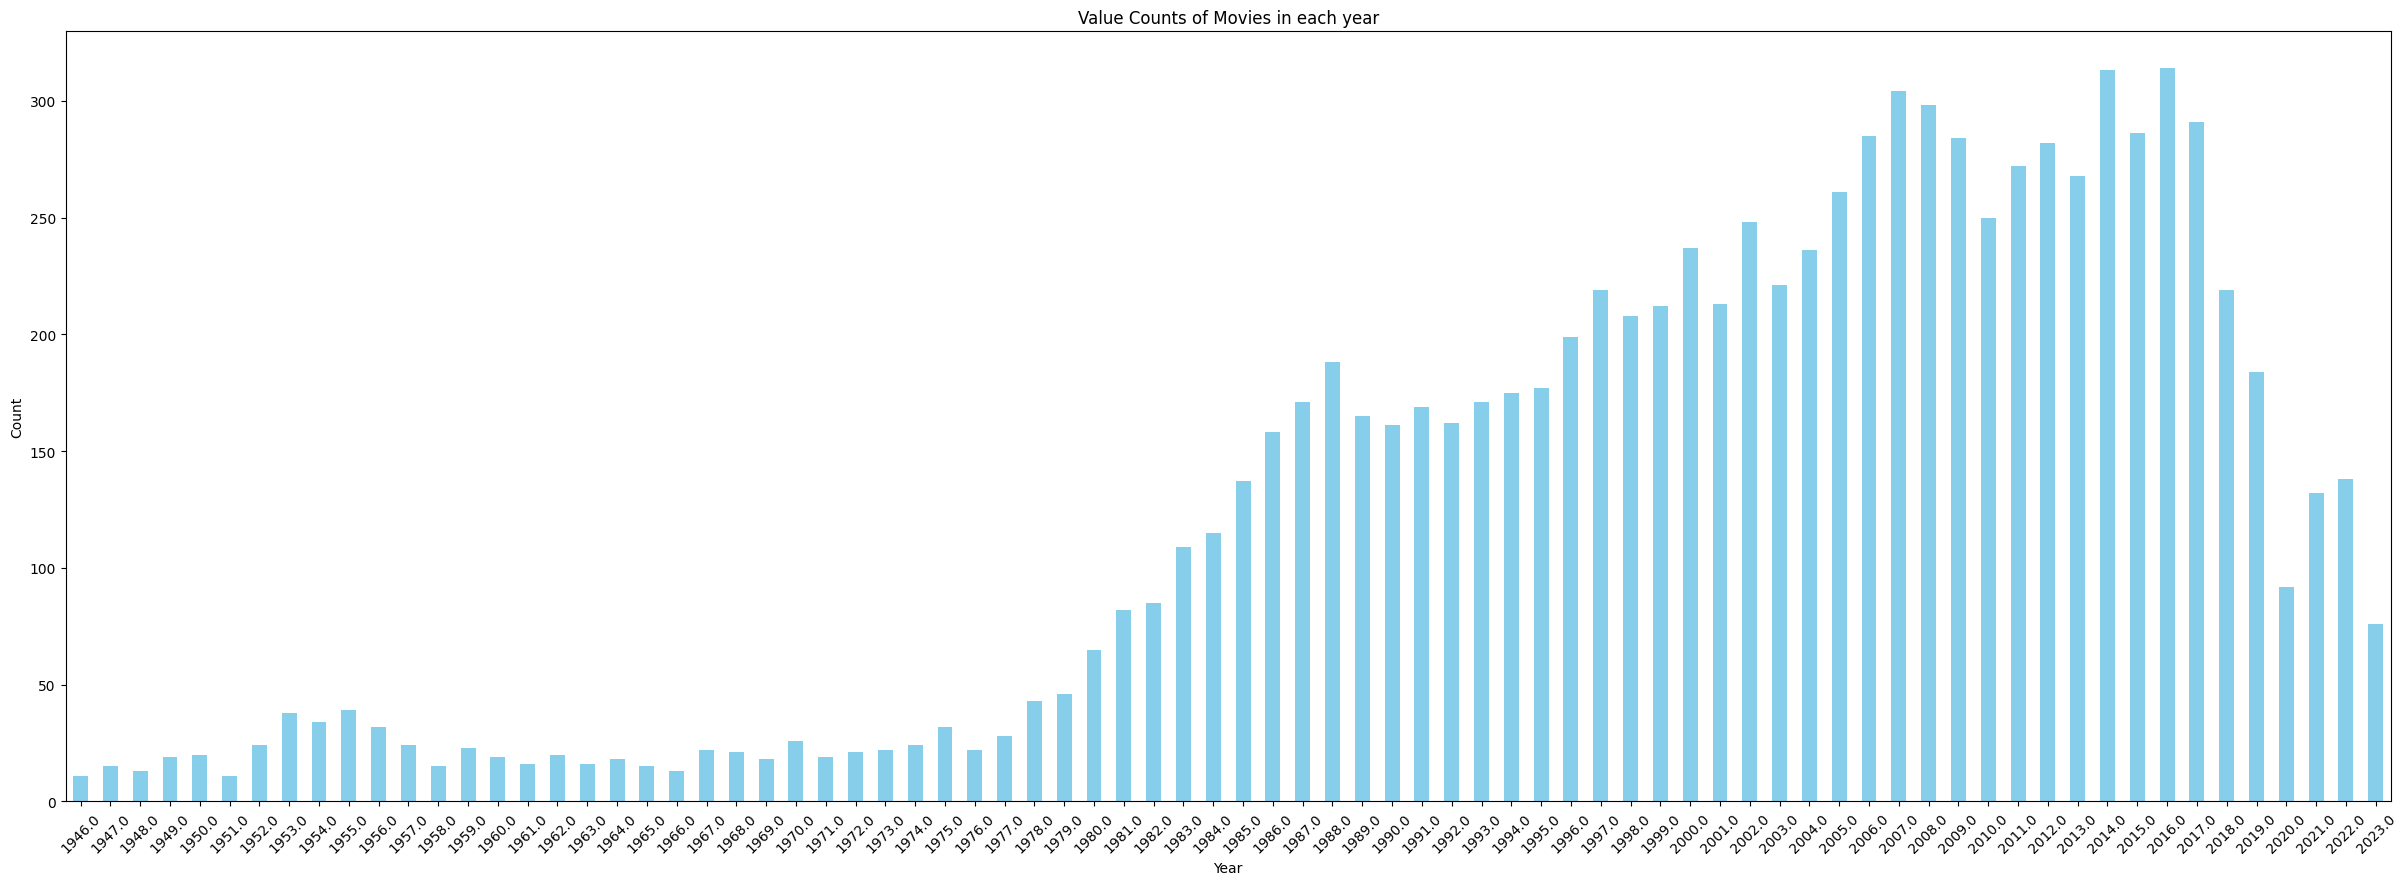

In [38]:
year_counts = movie_lens.loc[movie_lens['year_x'] > 1945, 'year_x'].value_counts().sort_index(ascending=True)

fig = plt.figure(figsize=(30,10))
year_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Value Counts of Movies in each year')
plt.xticks(rotation=45)
plt.show()